In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from finger_tapping.preprocessing import simple_pipeline, SUBJECTS
from finger_tapping.feature_preparation4 import extract_all_epoch_features, fit_motor_ica, DEFAULT_SAMPLING_RATE_HZ

from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

-----

### Baseline Delta Mean and Delta Variance Model

Reading 0 ... 23238  =      0.000 ...  2974.464 secs...
Reading 0 ... 18877  =      0.000 ...  2416.256 secs...
Reading 0 ... 18874  =      0.000 ...  2415.872 secs...
Reading 0 ... 23120  =      0.000 ...  2959.360 secs...
Reading 0 ... 23006  =      0.000 ...  2944.768 secs...


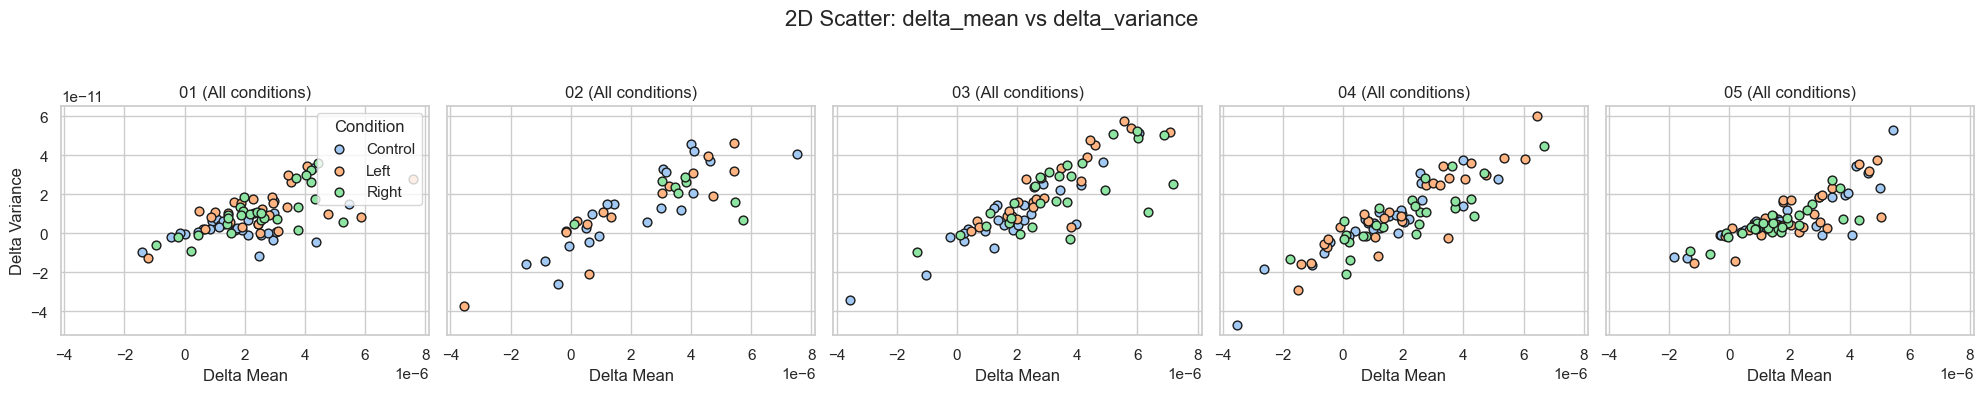

In [6]:
FEATURES_TO_PLOT  = ["delta_mean", "delta_variance"]
assert len(FEATURES_TO_PLOT) == 2, "Select exactly two features for 2D scatter."

# Swap axes in plot
SWAP_AXES = False
USE_CONTROL_ONLY  = False
CONTROL_FRACTION  = 0.5
RANDOM_SEED       = 42

sns.set(style="whitegrid")
palette_colors = sns.color_palette("pastel", n_colors=3)
condition_labels = ["Control", "Left", "Right"]
PALETTE = dict(zip(condition_labels, palette_colors))

rng = np.random.RandomState(RANDOM_SEED)

if not SWAP_AXES:
    X_IDX, Y_IDX = 0, 1
else:
    X_IDX, Y_IDX = 1, 0

# Extract features for all subjects and conditions
features_all = {}
for subj in SUBJECTS:
    ep_dict = simple_pipeline(subject = subj, save = False)
    ica_model, ic_l_idx, ic_r_idx = fit_motor_ica(ep_dict)

    ctrl_indices = None
    if USE_CONTROL_ONLY:
        ctrl_data = ep_dict["Control"].get_data(picks=["hbo","hbr"])
        n_ctrl = ctrl_data.shape[0]
        n_sel = int(round(n_ctrl * CONTROL_FRACTION))
        ctrl_indices= rng.choice(n_ctrl, n_sel, replace=False)

    features_all[subj] = {}
    for cond in condition_labels:
        if USE_CONTROL_ONLY and cond != "Control":
            continue
        data = ep_dict[cond].get_data(picks=["hbo","hbr"])
        if ctrl_indices is not None and cond == "Control":
            data = data[ctrl_indices]
        feats = []
        for epoch in data:
            fd = extract_all_epoch_features(epoch, sampling_rate_hz = DEFAULT_SAMPLING_RATE_HZ, ica_model = ica_model, ic_left_index = ic_l_idx, ic_right_index = ic_r_idx)
            feats.append([fd[f] for f in FEATURES_TO_PLOT])
        features_all[subj][cond] = np.array(feats)

all_points = np.vstack([
    features_all[subj][cond]
    for subj in SUBJECTS
    for cond in features_all[subj]
])
x0, x1 = all_points[:, X_IDX].min(), all_points[:, X_IDX].max()
y0, y1 = all_points[:, Y_IDX].min(), all_points[:, Y_IDX].max()
pad_x   = (x1 - x0) * 0.05
pad_y   = (y1 - y0) * 0.05

# PLOT
n_subj = len(SUBJECTS)
fig, axes = plt.subplots(1, n_subj, figsize=(4 * n_subj, 4), sharex=True, sharey=True)

for ax, subj in zip(axes, SUBJECTS):
    for cond, pts in features_all[subj].items():
        ax.scatter(pts[:, X_IDX], pts[:, Y_IDX], label=cond, color=PALETTE[cond], edgecolor="k", alpha=1, s=40)
    title_conds = "Control only" if USE_CONTROL_ONLY else "All conditions"
    ax.set_title(f"{subj} ({title_conds})")
    ax.set_xlim(x0 - pad_x, x1 + pad_x)
    ax.set_ylim(y0 - pad_y, y1 + pad_y)
    ax.set_xlabel(FEATURES_TO_PLOT[X_IDX].replace("_", " ").title())
    if ax is axes[0]:
        ax.set_ylabel(FEATURES_TO_PLOT[Y_IDX].replace("_", " ").title())
        ax.legend(title="Condition", loc="upper right", frameon=True)

fig.suptitle(
    f"2D Scatter: {FEATURES_TO_PLOT[X_IDX]} vs {FEATURES_TO_PLOT[Y_IDX]}",
    fontsize=16
)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

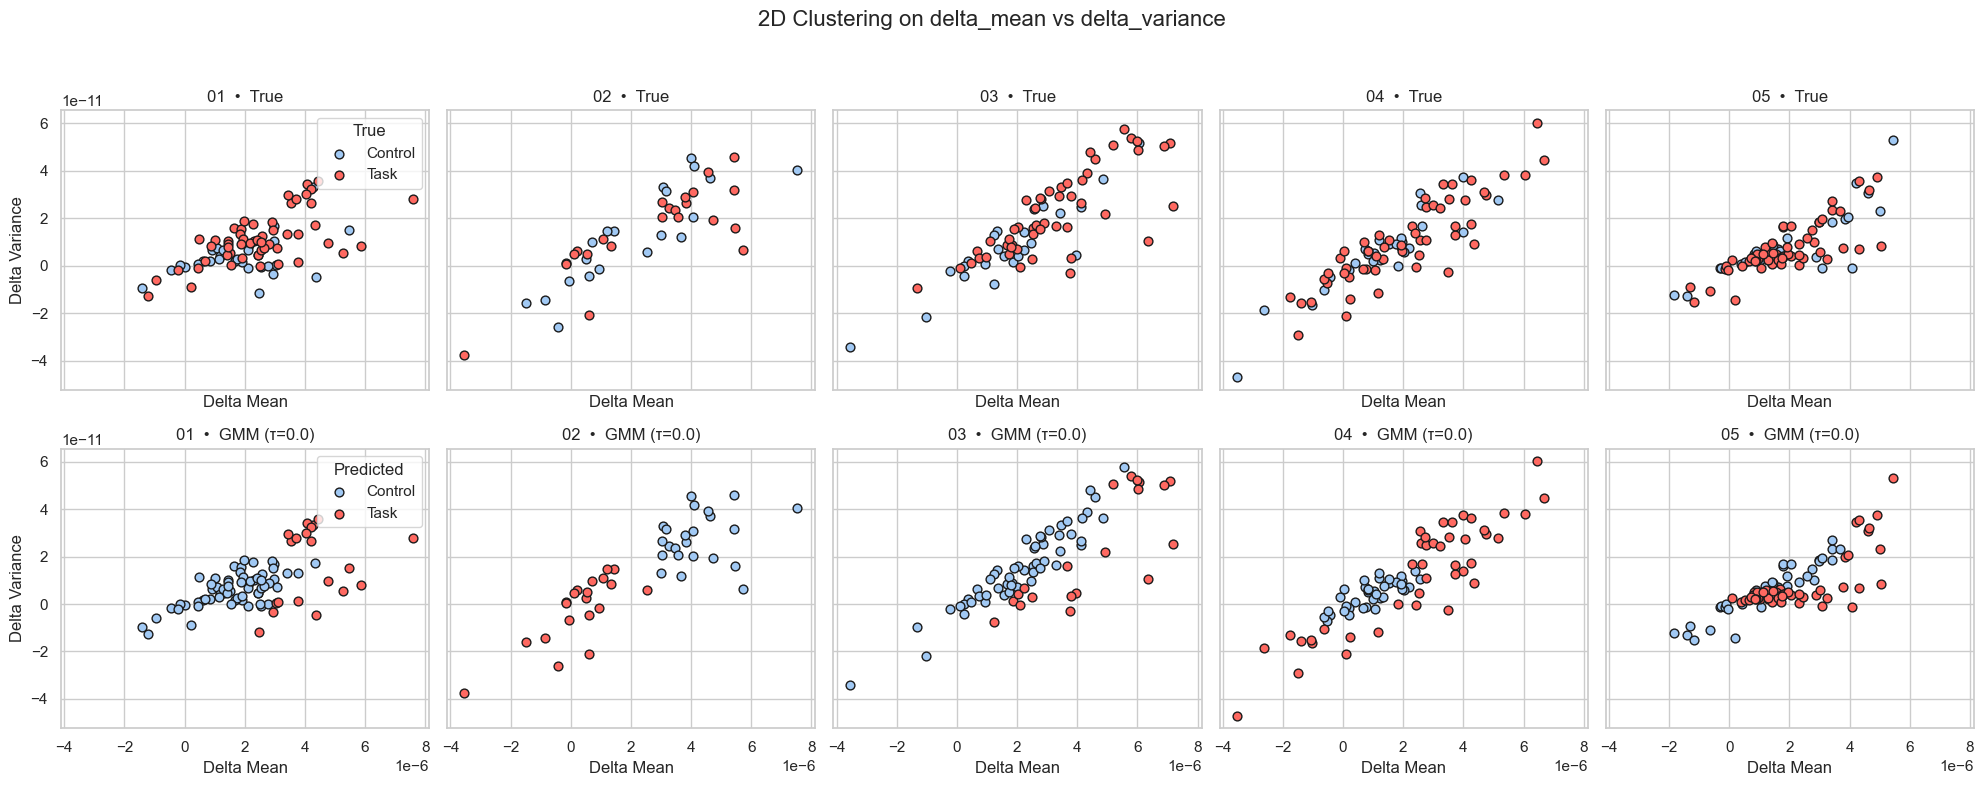

In [7]:
SWAP_AXES = False

FEATURES_TO_CLUSTER = ["delta_mean", "delta_variance"]

TAU = 0.0   # ≤0 for hard MAP assignment

sns.set(style="whitegrid")
CONTROL_COLOR = sns.color_palette("pastel", n_colors=1)[0]  # Pastel blue
TASK_COLOR = "#FF6961"                                    # pastel red

X_IDX, Y_IDX = (0, 1) if not SWAP_AXES else (1, 0)

n_subj = len(SUBJECTS)
fig, axes = plt.subplots(2, n_subj, figsize=(4 * n_subj, 8), sharex=True, sharey=True)

for col, subj in enumerate(SUBJECTS):
    X_parts, y_true = [], []
    for cond, arr in features_all[subj].items():
        label = 0 if cond == "Control" else 1
        X_parts.append(arr)
        y_true.extend([label] * arr.shape[0])
    X = np.vstack(X_parts)
    y_true = np.array(y_true)

    # Standardize and fit GMM
    scaler = StandardScaler().fit(X)
    X_std = scaler.transform(X)
    gmm = GaussianMixture(n_components = 3, covariance_type = "full", n_init = 20, max_iter = 500, reg_covar = 1e-6, random_state = RANDOM_SEED).fit(X_std)
    resp = gmm.predict_proba(X_std)
    ctrl_comp = int(np.argmax(resp[y_true == 0].mean(axis=0)))

    # Predict Control vs Task
    if TAU <= 0.0:
        clusters = gmm.predict(X_std)
        y_pred   = np.where(clusters == ctrl_comp, 0, 1)
    else:
        p_ctrl = resp[:, ctrl_comp]
        y_pred = np.where(p_ctrl >= TAU, 0, 1)

    # Plot True labels
    ax_true = axes[0, col]
    for lbl, color in zip([0, 1], [CONTROL_COLOR, TASK_COLOR]):
        mask = (y_true == lbl)
        ax_true.scatter(
            X[mask, X_IDX], X[mask, Y_IDX],
            color=color,
            edgecolor="k",
            alpha=1,
            s=40,
            label="Control" if lbl == 0 else "Task"
        )
    if col == 0:
        ax_true.legend(title="True", loc="upper right", frameon=True)
    ax_true.set_title(f"{subj}  •  True")
    ax_true.set_xlabel(FEATURES_TO_CLUSTER[X_IDX].replace("_", " ").title())
    if col == 0:
        ax_true.set_ylabel(FEATURES_TO_CLUSTER[Y_IDX].replace("_", " ").title())

    # Plot GMM predicted labels
    ax_pred = axes[1, col]
    for lbl, color in zip([0, 1], [CONTROL_COLOR, TASK_COLOR]):
        mask = (y_pred == lbl)
        ax_pred.scatter(
            X[mask, X_IDX], X[mask, Y_IDX],
            color=color,
            edgecolor="k",
            alpha=1,
            s=40,
            label="Control" if lbl == 0 else "Task"
        )
    if col == 0:
        ax_pred.legend(title="Predicted", loc="upper right", frameon=True)
    ax_pred.set_title(f"{subj}  •  GMM (τ={TAU})")
    ax_pred.set_xlabel(FEATURES_TO_CLUSTER[X_IDX].replace("_", " ").title())
    if col == 0:
        ax_pred.set_ylabel(FEATURES_TO_CLUSTER[Y_IDX].replace("_", " ").title())

fig.suptitle(
    f"2D Clustering on {FEATURES_TO_CLUSTER[X_IDX]} vs {FEATURES_TO_CLUSTER[Y_IDX]}", 
    fontsize=16
)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### Unresponsive Test

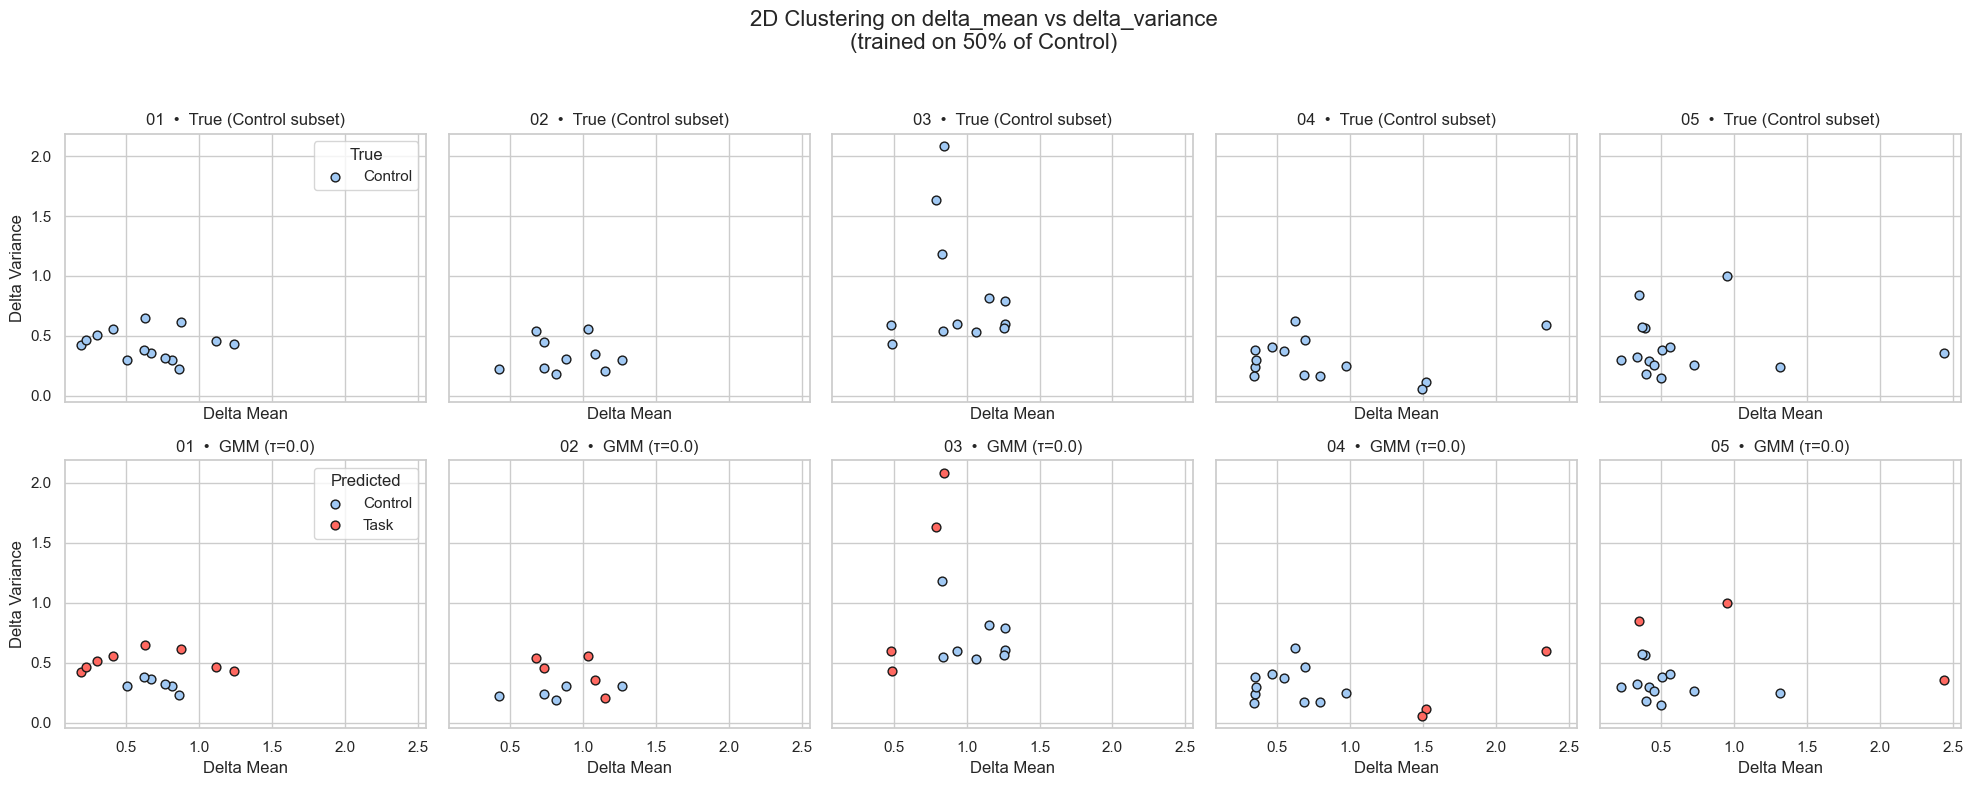

In [16]:
SWAP_AXES           = False
FEATURES_TO_CLUSTER = ["delta_mean", "delta_variance"]
TAU                 = 0.0   
CONTROL_FRACTION    = 0.5    
RANDOM_SEED         = 42

sns.set(style="whitegrid")
pastel3        = sns.color_palette("pastel", n_colors=3)
CONTROL_COLOR  = pastel3[0]    
TASK_COLOR     = "#FF6961" 

rng = np.random.RandomState(RANDOM_SEED)

X_IDX, Y_IDX = (0, 1) if not SWAP_AXES else (1, 0)

n_subj = len(SUBJECTS)
fig, axes = plt.subplots(2, n_subj, figsize=(4 * n_subj, 8), sharex=True, sharey=True)

for col, subj in enumerate(SUBJECTS):
    # Load only control data for the current subject
    X_ctrl = features_all[subj]["Control"]
    n_ctrl = X_ctrl.shape[0]
    idx_all = np.arange(n_ctrl)

    # Sample a random subset for training
    n_train = int(round(n_ctrl * CONTROL_FRACTION))
    train_idx = rng.choice(idx_all, size=n_train, replace=False)

    # Standardize on training set
    scaler = StandardScaler().fit(X_ctrl[train_idx])
    X_std  = scaler.transform(X_ctrl)

    # Fit 2-component GMM on control subset
    gmm = GaussianMixture(n_components = 3, covariance_type = "full", random_state = RANDOM_SEED, n_init = 20, reg_covar = 1e-6).fit(X_std[train_idx])

    # Determine which cluster is the “control”
    clusters_train = gmm.predict(X_std[train_idx])
    ctrl_comp = np.bincount(clusters_train).argmax()

    # Predict on the same control subset
    if TAU <= 0.0:
        cluster_ids = gmm.predict(X_std[train_idx])
        y_pred = np.where(cluster_ids == ctrl_comp, 0, 1)
    else:
        resp = gmm.predict_proba(X_std[train_idx])
        y_pred = np.where(resp[:, ctrl_comp] >= TAU, 0, 1)

    X_plot = X_ctrl[train_idx]
    y_true_plot = np.zeros_like(y_pred)  # all true labels are 0 (control)

    # Plot TRUE labels (only control subset)
    ax_true = axes[0, col]
    ax_true.scatter(
        X_plot[:, X_IDX], X_plot[:, Y_IDX],
        color=CONTROL_COLOR,
        edgecolor="k",
        alpha=1,
        s=40,
        label="Control"
    )
    if col == 0:
        ax_true.legend(title="True", loc="upper right", frameon=True)
    ax_true.set_title(f"{subj}  •  True (Control subset)")
    ax_true.set_xlabel(FEATURES_TO_CLUSTER[X_IDX].replace("_", " ").title())
    if col == 0:
        ax_true.set_ylabel(FEATURES_TO_CLUSTER[Y_IDX].replace("_", " ").title())

    # Plot PREDICTED labels (control subset)
    ax_pred = axes[1, col]
    for lbl, color in zip([0, 1], [CONTROL_COLOR, TASK_COLOR]):
        mask = (y_pred == lbl)
        if mask.any():
            ax_pred.scatter(
                X_plot[mask, X_IDX], X_plot[mask, Y_IDX],
                color=color,
                edgecolor="k",
                alpha=1,
                s=40,
                label="Control" if lbl == 0 else "Task"
            )
    if col == 0:
        ax_pred.legend(title="Predicted", loc="upper right", frameon=True)
    ax_pred.set_title(f"{subj}  •  GMM (τ={TAU})")
    ax_pred.set_xlabel(FEATURES_TO_CLUSTER[X_IDX].replace("_", " ").title())
    if col == 0:
        ax_pred.set_ylabel(FEATURES_TO_CLUSTER[Y_IDX].replace("_", " ").title())

fig.suptitle(
    f"2D Clustering on {FEATURES_TO_CLUSTER[X_IDX]} vs {FEATURES_TO_CLUSTER[Y_IDX]}\n"
    f"(trained on {CONTROL_FRACTION*100:.0f}% of Control)",
    fontsize=16
)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

------

### ICA Power Features Model

Reading 0 ... 23238  =      0.000 ...  2974.464 secs...
Reading 0 ... 18877  =      0.000 ...  2416.256 secs...
Reading 0 ... 18874  =      0.000 ...  2415.872 secs...
Reading 0 ... 23120  =      0.000 ...  2959.360 secs...
Reading 0 ... 23006  =      0.000 ...  2944.768 secs...


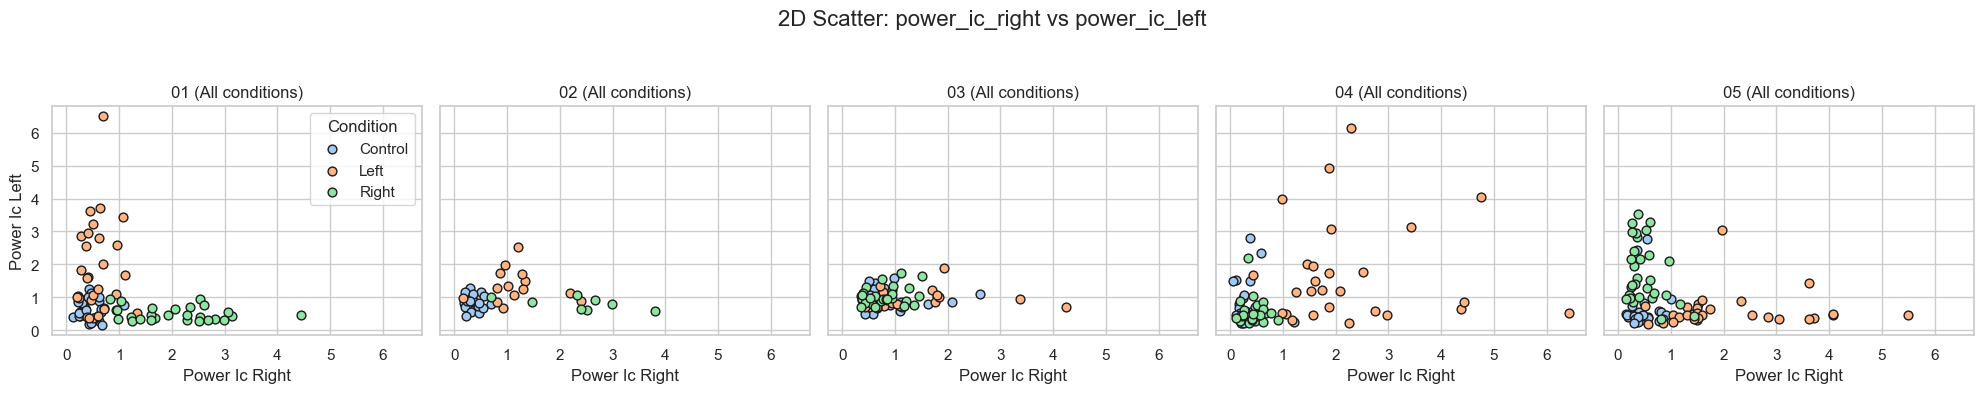

In [9]:
FEATURES_TO_PLOT  = ["power_ic_left", "power_ic_right"]
assert len(FEATURES_TO_PLOT) == 2, "Select exactly two features for 2D scatter."

SWAP_AXES         = True
USE_CONTROL_ONLY  = False
CONTROL_FRACTION  = 0.5
RANDOM_SEED       = 42

sns.set(style="whitegrid")
palette_colors = sns.color_palette("pastel", n_colors=3)
condition_labels = ["Control", "Left", "Right"]
PALETTE = dict(zip(condition_labels, palette_colors))

rng = np.random.RandomState(RANDOM_SEED)

if not SWAP_AXES:
    X_IDX, Y_IDX = 0, 1
else:
    X_IDX, Y_IDX = 1, 0

features_all = {}
for subj in SUBJECTS:
    ep_dict      = simple_pipeline(subject=subj, save=False)
    ica_model, ic_l_idx, ic_r_idx = fit_motor_ica(ep_dict)

    ctrl_indices = None
    if USE_CONTROL_ONLY:
        ctrl_data   = ep_dict["Control"].get_data(picks=["hbo","hbr"])
        n_ctrl      = ctrl_data.shape[0]
        n_sel       = int(round(n_ctrl * CONTROL_FRACTION))
        ctrl_indices= rng.choice(n_ctrl, n_sel, replace=False)

    features_all[subj] = {}
    for cond in condition_labels:
        if USE_CONTROL_ONLY and cond != "Control":
            continue
        data = ep_dict[cond].get_data(picks=["hbo","hbr"])
        if ctrl_indices is not None and cond == "Control":
            data = data[ctrl_indices]
        feats = []
        for epoch in data:
            fd = extract_all_epoch_features(
                epoch,
                sampling_rate_hz=DEFAULT_SAMPLING_RATE_HZ,
                ica_model=ica_model,
                ic_left_index=ic_l_idx,
                ic_right_index=ic_r_idx
            )
            feats.append([fd[f] for f in FEATURES_TO_PLOT])
        features_all[subj][cond] = np.array(feats)

all_points = np.vstack([
    features_all[subj][cond]
    for subj in SUBJECTS
    for cond in features_all[subj]
])
x0, x1 = all_points[:, X_IDX].min(), all_points[:, X_IDX].max()
y0, y1 = all_points[:, Y_IDX].min(), all_points[:, Y_IDX].max()
pad_x   = (x1 - x0) * 0.05
pad_y   = (y1 - y0) * 0.05

n_subj = len(SUBJECTS)
fig, axes = plt.subplots(
    1, n_subj,
    figsize=(4 * n_subj, 4),
    sharex=True, sharey=True
)

for ax, subj in zip(axes, SUBJECTS):
    for cond, pts in features_all[subj].items():
        ax.scatter(
            pts[:, X_IDX], pts[:, Y_IDX],
            label=cond,
            color=PALETTE[cond],
            edgecolor="k",
            alpha=1,
            s=40
        )
    title_conds = "Control only" if USE_CONTROL_ONLY else "All conditions"
    ax.set_title(f"{subj} ({title_conds})")
    ax.set_xlim(x0 - pad_x, x1 + pad_x)
    ax.set_ylim(y0 - pad_y, y1 + pad_y)
    ax.set_xlabel(FEATURES_TO_PLOT[X_IDX].replace("_", " ").title())
    if ax is axes[0]:
        ax.set_ylabel(FEATURES_TO_PLOT[Y_IDX].replace("_", " ").title())
        ax.legend(title="Condition", loc="upper right", frameon=True)

fig.suptitle(
    f"2D Scatter: {FEATURES_TO_PLOT[X_IDX]} vs {FEATURES_TO_PLOT[Y_IDX]}",
    fontsize=16
)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

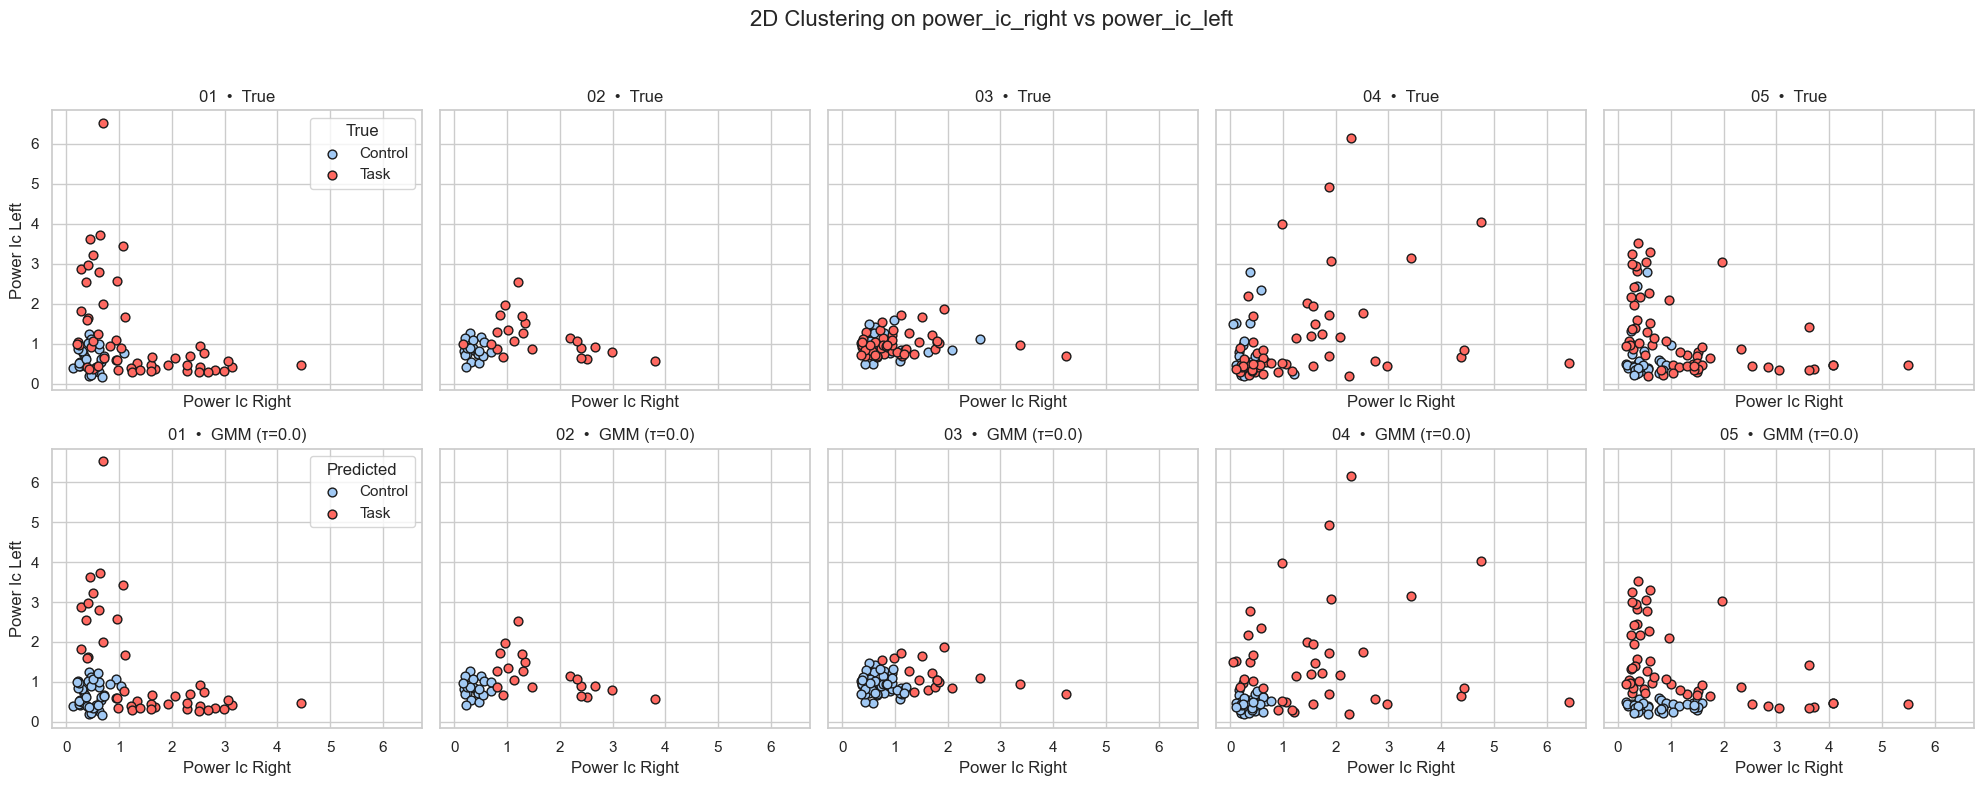

In [ ]:
SWAP_AXES = True

FEATURES_TO_CLUSTER = ["power_ic_left", "power_ic_right"]

TAU = 0.0 

sns.set(style="whitegrid")
CONTROL_COLOR = sns.color_palette("pastel", n_colors=1)[0]    # pastel blue
TASK_COLOR    = "#FF6961"                                   # pastel red

X_IDX, Y_IDX = (0, 1) if not SWAP_AXES else (1, 0)

n_subj = len(SUBJECTS)
fig, axes = plt.subplots(
    2, n_subj,
    figsize=(4 * n_subj, 8),
    sharex=True, sharey=True
)

for col, subj in enumerate(SUBJECTS):
    X_parts, y_true = [], []
    for cond, arr in features_all[subj].items():
        label = 0 if cond == "Control" else 1
        X_parts.append(arr)
        y_true.extend([label] * arr.shape[0])
    X      = np.vstack(X_parts)
    y_true = np.array(y_true)

    scaler = StandardScaler().fit(X)
    X_std  = scaler.transform(X)
    gmm    = GaussianMixture(
                n_components=3,
                covariance_type="full",
                n_init=20,
                max_iter=500,
                reg_covar=1e-6,
                random_state=RANDOM_SEED
             ).fit(X_std)
    resp      = gmm.predict_proba(X_std)
    ctrl_comp = int(np.argmax(resp[y_true == 0].mean(axis=0)))

    if TAU <= 0.0:
        clusters = gmm.predict(X_std)
        y_pred   = np.where(clusters == ctrl_comp, 0, 1)
    else:
        p_ctrl = resp[:, ctrl_comp]
        y_pred = np.where(p_ctrl >= TAU, 0, 1)

    ax_true = axes[0, col]
    for lbl, color in zip([0, 1], [CONTROL_COLOR, TASK_COLOR]):
        mask = (y_true == lbl)
        ax_true.scatter(
            X[mask, X_IDX], X[mask, Y_IDX],
            color=color,
            edgecolor="k",
            alpha=1,
            s=40,
            label="Control" if lbl == 0 else "Task"
        )
    if col == 0:
        ax_true.legend(title="True", loc="upper right", frameon=True)
    ax_true.set_title(f"{subj}  •  True")
    ax_true.set_xlabel(FEATURES_TO_CLUSTER[X_IDX].replace("_", " ").title())
    if col == 0:
        ax_true.set_ylabel(FEATURES_TO_CLUSTER[Y_IDX].replace("_", " ").title())

    ax_pred = axes[1, col]
    for lbl, color in zip([0, 1], [CONTROL_COLOR, TASK_COLOR]):
        mask = (y_pred == lbl)
        ax_pred.scatter(
            X[mask, X_IDX], X[mask, Y_IDX],
            color=color,
            edgecolor="k",
            alpha=1,
            s=40,
            label="Control" if lbl == 0 else "Task"
        )
    if col == 0:
        ax_pred.legend(title="Predicted", loc="upper right", frameon=True)
    ax_pred.set_title(f"{subj}  •  GMM (τ={TAU})")
    ax_pred.set_xlabel(FEATURES_TO_CLUSTER[X_IDX].replace("_", " ").title())
    if col == 0:
        ax_pred.set_ylabel(FEATURES_TO_CLUSTER[Y_IDX].replace("_", " ").title())

fig.suptitle(
    f"2D Clustering on {FEATURES_TO_CLUSTER[X_IDX]} vs {FEATURES_TO_CLUSTER[Y_IDX]}", 
    fontsize=16
)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### Unresponsive Test

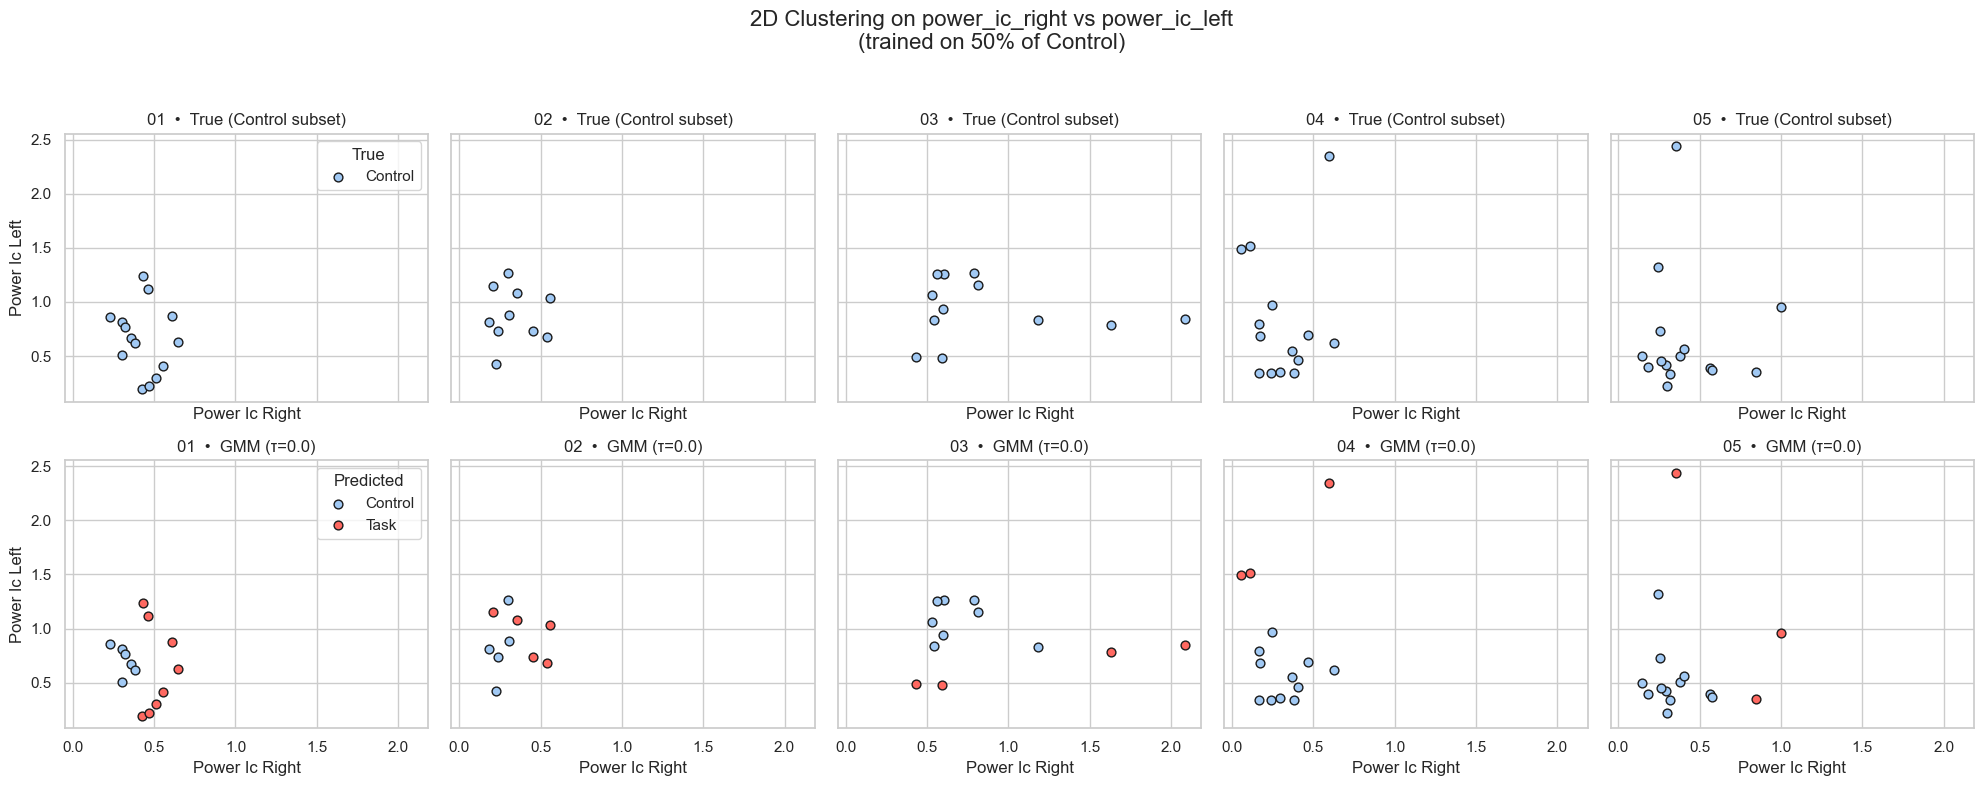

In [15]:
SWAP_AXES           = True
FEATURES_TO_CLUSTER = ["power_ic_left", "power_ic_right"]
TAU                 = 0.0   
CONTROL_FRACTION    = 0.5    
RANDOM_SEED         = 42

sns.set(style="whitegrid")
pastel3        = sns.color_palette("pastel", n_colors=3)
CONTROL_COLOR  = pastel3[0]   
TASK_COLOR     = "#FF6961"   

rng = np.random.RandomState(RANDOM_SEED)

X_IDX, Y_IDX = (0, 1) if not SWAP_AXES else (1, 0)

n_subj = len(SUBJECTS)
fig, axes = plt.subplots(
    2, n_subj,
    figsize=(4 * n_subj, 8),
    sharex=True, sharey=True
)

for col, subj in enumerate(SUBJECTS):
    X_ctrl = features_all[subj]["Control"]             
    n_ctrl = X_ctrl.shape[0]
    idx_all = np.arange(n_ctrl)

    n_train   = int(round(n_ctrl * CONTROL_FRACTION))
    train_idx = rng.choice(idx_all, size=n_train, replace=False)

    scaler = StandardScaler().fit(X_ctrl[train_idx])
    X_std  = scaler.transform(X_ctrl)

    gmm = GaussianMixture(
        n_components=3,
        covariance_type="full",
        random_state=RANDOM_SEED,
        n_init=20,
        reg_covar=1e-6
    ).fit(X_std[train_idx])

    clusters_train = gmm.predict(X_std[train_idx])
    ctrl_comp = np.bincount(clusters_train).argmax()

    if TAU <= 0.0:
        cluster_ids = gmm.predict(X_std[train_idx])
        y_pred = np.where(cluster_ids == ctrl_comp, 0, 1)
    else:
        resp   = gmm.predict_proba(X_std[train_idx])
        y_pred = np.where(resp[:, ctrl_comp] >= TAU, 0, 1)

    X_plot     = X_ctrl[train_idx]
    y_true_plot = np.zeros_like(y_pred)  # all true labels are 0 (control)

    # ── 6) Plot TRUE labels (only control subset) ─────────────────────────
    ax_true = axes[0, col]
    ax_true.scatter(
        X_plot[:, X_IDX], X_plot[:, Y_IDX],
        color=CONTROL_COLOR,
        edgecolor="k",
        alpha=1,
        s=40,
        label="Control"
    )
    if col == 0:
        ax_true.legend(title="True", loc="upper right", frameon=True)
    ax_true.set_title(f"{subj}  •  True (Control subset)")
    ax_true.set_xlabel(FEATURES_TO_CLUSTER[X_IDX].replace("_", " ").title())
    if col == 0:
        ax_true.set_ylabel(FEATURES_TO_CLUSTER[Y_IDX].replace("_", " ").title())

    # ── 7) Plot PREDICTED labels (control subset) ─────────────────────────
    ax_pred = axes[1, col]
    for lbl, color in zip([0, 1], [CONTROL_COLOR, TASK_COLOR]):
        mask = (y_pred == lbl)
        if mask.any():
            ax_pred.scatter(
                X_plot[mask, X_IDX], X_plot[mask, Y_IDX],
                color=color,
                edgecolor="k",
                alpha=1,
                s=40,
                label="Control" if lbl == 0 else "Task"
            )
    if col == 0:
        ax_pred.legend(title="Predicted", loc="upper right", frameon=True)
    ax_pred.set_title(f"{subj}  •  GMM (τ={TAU})")
    ax_pred.set_xlabel(FEATURES_TO_CLUSTER[X_IDX].replace("_", " ").title())
    if col == 0:
        ax_pred.set_ylabel(FEATURES_TO_CLUSTER[Y_IDX].replace("_", " ").title())

# ── Final formatting ───────────────────────────────────────────────────────
fig.suptitle(
    f"2D Clustering on {FEATURES_TO_CLUSTER[X_IDX]} vs {FEATURES_TO_CLUSTER[Y_IDX]}\n"
    f"(trained on {CONTROL_FRACTION*100:.0f}% of Control)",
    fontsize=16
)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

---